In [1]:
#| output: false
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from trialframe import multivalue_xs, hierarchical_assign, get_index_level, get_epoch_data
from src import crystal_models
from src.io import generic_preproc, get_targets
from sklearn.decomposition import PCA
from omegaconf import DictConfig
%matplotlib inline

In [4]:
args = DictConfig({
    'trialframe_dir': Path('../data/trialframe'),
    'dataset':  'Dwight_2025-01-07',
    # 'dataset': 'Prez_2025-04-16',
    # 'dataset':  'Sulley_2025-05-06',
    # 'dataset': 'Prez_2022-07-21',
    'composition_config': Path('../conf/trialframe_partition.yaml'),
})

In [7]:
preproc = generic_preproc(args)
preproc

signal                                                                                                                                                          hand position  \
channel                                                                                                                                                                     x   
block                                trial_id time                   monkey session date trial datetime      trial name task memory state                                       
reward-type-medium-large-cst-rtt-dco 153      0 days 00:00:00.650000 Dwight 2025-01-07   2025-01-07 13:21:17 CST R1T1   CST  False  Hold Center (Ambiguous Cue)    123.424123   
                                              0 days 00:00:00.660000 Dwight 2025-01-07   2025-01-07 13:21:17 CST R1T1   CST  False  Hold Center (Ambiguous Cue)    123.147077   
                                              0 days 00:00:00.670000 Dwight 2025-01-07   2025-01-07 13:21:17 CST R1T1   CST  False  Hold Center (Ambiguous Cue)    122.833072   
                                              0 days 00:00:00.680000 Dwight 2025-01-07   2025-01-07 13:21:17 CST R1T1   CST  False  Hold Center (Ambiguous Cue)    122.448834   
                                              0 days 00:00:00.690000 Dwight 2025-01-07   2025-01-07 13:21:17 CST R1T1   CST  False  Hold Center (Ambiguous Cue)    122.242283   
...                                                                                                                                                                       ...   
reward-type-medium-cst-rtt-dco       143      0 days 00:00:02.240000 Dwight 2025-01-07   2025-01-07 13:19:59 R2T1       DCO  False  After Success Timeout           60.464195   
                                              0 days 00:00:02.250000 Dwight 2025-01-07   2025-01-07 13:19:59 R2T1       DCO  False  After Success Timeout           60.770696   
                                              0 days 00:00:02.260000 Dwight 2025-01-07   2025-01-07 13:19:59 R2T1       DCO  False  After Success Timeout           61.086601   
                                              0 days 00:00:02.270000 Dwight 2025-01-07   2025-01-07 13:19:59 R2T1       DCO  False  After Success Timeout           61.426179   
                                              0 days 00:00:02.280000 Dwight 2025-01-07   2025-01-07 13:19:59 R2T1       DCO  False  After Success Timeout           61.728137   

signal                                                                                                                                                                       \
channel                                                                                                                                                                   y   
block                                trial_id time                   monkey session date trial datetime      trial name task memory state                                     
reward-type-medium-large-cst-rtt-dco 153      0 days 00:00:00.650000 Dwight 2025-01-07   2025-01-07 13:21:17 CST R1T1   CST  False  Hold Center (Ambiguous Cue)  894.907392   
                                              0 days 00:00:00.660000 Dwight 2025-01-07   2025-01-07 13:21:17 CST R1T1   CST  False  Hold Center (Ambiguous Cue)  896.197847   
                                              0 days 00:00:00.670000 Dwight 2025-01-07   2025-01-07 13:21:17 CST R1T1   CST  False  Hold Center (Ambiguous Cue)  897.229687   
                                              0 days 00:00:00.680000 Dwight 2025-01-07   2025-01-07 13:21:17 CST R1T1   CST  False  Hold Center (Ambiguous Cue)  898.003551   
                                              0 days 00:00:00.690000 Dwight 2025-01-07   2025-01-07 13:21:17 CST R1T1   CST  False  Hold Center (Ambiguous Cue)  898.552504   
...                                                                                                                      

In [10]:
# cst_kin = (
#     preproc
#     .xs(level='task', key='CST')
#     [['hand position','cst cursor position']]
#     .xs(axis=1, level='channel', key='x')
#     .stack()
#     .to_frame('horizontal position')
# )
# 
# trial_ids = (
#     cst_kin
#     .groupby('trial_id')
#     .nth(0)
#     .pipe(get_index_level, level='trial_id')
#     .sample(n=10)
#     .values
# )
# 
# g = sns.relplot(
#     data=cst_kin.pipe(multivalue_xs, level='trial_id', keys=trial_ids),
#     x='time',
#     y='horizontal position',
#     hue='signal',
#     hue_order=['cst cursor position','hand position'],
#     kind='line',
#     row='trial_id',
#     height=1.5,
#     aspect=4,
# )
# sns.despine(fig=g.figure)

In [ ]:
horz_kin = (
    preproc
    .assign(**{
        'target direction': target_dir,
    })
    .set_index('target direction', append=True)
    .xs(axis=1, level='channel', key='x')
    .pipe(get_epoch_data, epochs={
        'hold': ('Target On', slice(pd.to_timedelta('-250ms'), pd.to_timedelta('250ms'))),
        'trial': ('Go Cue', slice(pd.to_timedelta('-500ms'), pd.to_timedelta('1000ms'))),
    })
)

import altair as alt
alt.data_transformers.enable('json')

alt.Chart(
    horz_kin
    .reset_index()
    .assign(
        time=lambda df: df['time'].dt.total_seconds(),
    )
).mark_line().encode(
    x='hand velocity:Q',
    y='hand acceleration:Q',
    color='target direction:N',
    row='phase:N',
    column='task:N',
    detail='trial_id',
    order='time',
    opacity=alt.value(0.1)
).configure_axis(
    grid=False,
).configure_view(
    stroke=None,
)

alt.Chart(...)

In [19]:
softnormer = crystal_models.SoftnormScaler()
neural_data = (
    preproc
    .assign(**{
        'target direction': target_dir,
    })
    .set_index('target direction', append=True)
    ['motor cortex']
    .pipe(softnormer.fit_transform)
)
neural_data

channel                                                                                                  ch4u1  \
block              trial_id time                   task state                       target direction             
memory-cst-rtt-dco 2        0 days 00:00:00.770000 CST  Hold Center (Ambiguous Cue) NaN               0.612263   
                            0 days 00:00:00.780000 CST  Hold Center (Ambiguous Cue) NaN               0.622367   
                            0 days 00:00:00.790000 CST  Hold Center (Ambiguous Cue) NaN               0.623717   
                            0 days 00:00:00.800000 CST  Hold Center (Ambiguous Cue) NaN               0.618953   
                            0 days 00:00:00.810000 CST  Hold Center (Ambiguous Cue) NaN               0.613723   
...                                                                                                        ...   
                   289      0 days 00:00:03.410000 DCO  Success                     -90.0             0.421708   
                            0 days 00:00:03.420000 DCO  Success                     -90.0             0.410839   
                            0 days 00:00:03.430000 DCO  Success                     -90.0             0.408580   
                            0 days 00:00:03.440000 DCO  Success                     -90.0             0.415510   
                            0 days 00:00:03.450000 DCO  Success                     -90.0             0.425256   

channel                                                                                                  ch5u1  \
block              trial_id time                   task state                       target direction             
memory-cst-rtt-dco 2        0 days 00:00:00.770000 CST  Hold Center (Ambiguous Cue) NaN               0.005473   
                            0 days 00:00:00.780000 CST  Hold Center (Ambiguous Cue) NaN               0.005165   
                            0 days 00:00:00.790000 CST  Hold Center (Ambiguous Cue) NaN               0.004927   
                            0 days 00:00:00.800000 CST  Hold Center (Ambiguous Cue) NaN               0.004599   
                            0 days 00:00:00.810000 CST  Hold Center (Ambiguous Cue) NaN               0.003924   
...                                                                                                        ...   
                   289      0 days 00:00:03.410000 DCO  Success                     -90.0             0.006831   
                            0 days 00:00:03.420000 DCO  Success                     -90.0             0.006207   
                            0 days 00:00:03.430000 DCO  Success                     -90.0             0.006754   
                            0 days 00:00:03.440000 DCO  Success                     -90.0             0.008330   
                            0 days 00:00:03.450000 DCO  Success                     -90.0             0.010624   

channel                                                                                                  ch5u2  \
block              trial_id time                   task state                       target direction             
memory-cst-rtt-dco 2        0 days 00:00:00.770000 CST  Hold Center (Ambiguous Cue) NaN               0.090984   
                            0 days 00:00:00.780000 CST  Hold Center (Ambiguous Cue) NaN               0.089769   
                            0 days 00:00:00.790000 CST  Hold Center (Ambiguous Cue) NaN               0.087921   
                            0 days 00:00:00.800000 CST  Hold Center (Ambiguous Cue) NaN               0.083441   
                            0 days 00:00:00.810000 CST  Hold Center (Ambiguous Cue) NaN               0.077093   
...                                                                                                        ...   
                   289      0 days 00:00:03.410000 DCO  Success                     -90.0             0.039936   
        

In [ ]:
# alt.Chart(
#     plot_data
#     .rename(columns=lambda col: f'component {col}')
#     .reset_index()
#     .assign(
#         time=lambda df: df['time'].dt.total_seconds(),
#     )
# ).mark_line().encode(
#     x='time:Q',
#     y='component 0:Q',
#     color=alt.Color('target direction:N'),
#     # color=alt.Color('task:N').scale(scheme='category10').sort(['CST','RTT','DCO']),
#     row='space:N',
#     column='task:N',
#     detail='trial_id',
#     order='time',
#     opacity=alt.value(0.1),
# ).configure_axis(
#     grid=False,
# ).configure_view(
#     stroke=None,
# )

In [30]:
from sklearn.model_selection import cross_val_predict, cross_val_score, LeaveOneGroupOut
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline, FunctionTransformer
from sklearn.metrics import r2_score

move_decoder = LinearRegression()
full_decoder = LinearRegression()

trial_data = (
    preproc
    .pipe(get_epoch_data, epochs={
        'trial': ('Go Cue', slice(pd.to_timedelta('-1000ms'),pd.to_timedelta('3000ms'))),
    })
)

def model_score(tf, preprocessor=None, model=LinearRegression(), cv=LeaveOneGroupOut()):
    if preprocessor is None:
        preprocessor = FunctionTransformer()

    return cross_val_score(
        model,
        X=(
            tf
            ['motor cortex']
            .pipe(preprocessor.transform)
        ),
        y=(
            tf
            [('hand velocity','x')]
            .to_frame('hand velocity')
        ),
        groups=get_index_level(tf, level='trial_id'),
        cv=cv,
    )

partition_decoder_preprocessor = make_pipeline(
    softnormer,
    partition_model,
)
move_decoder_preprocessor = make_pipeline(
    softnormer,
    partition_model,
    FunctionTransformer(lambda x: x.xs(axis=1, level='space', key='move_unique')),
)
full_decoder_preprocessor = softnormer
preprocessors = {
    'partition space decoder': partition_decoder_preprocessor,
    'move space decoder': move_decoder_preprocessor,
    'full space decoder': full_decoder_preprocessor,
}

# pred_data = pd.concat(
#     {
#         key: (
#             trial_data
#             .groupby('task', group_keys=False)
#             .apply(lambda x: model_score(x, preprocessor=preprocessor))
#         )
#         for key, preprocessor in preprocessors.items()
#     },
#     axis=1,
#     # levels=['model','signal'],
# ) # type: ignore

# true_data = trial_data[('hand velocity','x')]
# scores = (
#     pred_data
#     .xs(axis=1, level='signal', key='hand velocity')
#     .stack(level='model')
#     .to_frame('predicted') # type: ignore
#     .assign(true=true_data)
#     .groupby(['trial_id','model'])
#     .apply(lambda group_set: r2_score(group_set['true'],group_set['predicted'])) # type: ignore
# )
# pred_data

cv = LeaveOneGroupOut()
move_scores = pd.concat(
    {
        key: (
            trial_data
            .groupby('task')
            .apply(model_score, preprocessor=preprocessor, cv=cv)
        )
        for key, preprocessor in preprocessors.items()
    },
    axis=1,
)
# move_scores.mean()
# (
#     trial_data
#     .groupby('task')
#     .apply(model_score, preprocessor=move_decoder_preprocessor, cv=cv)
#     .apply(lambda x: x.shape)
# )

,partition space decoder,move space decoder,full space decoder,ratio
task,,,,
CST,0.563827,0.513611,0.606039,0.980116
DCO,-0.546163,-0.581055,-0.24718,2.091921
RTT,0.755894,0.70424,0.81606,0.834314


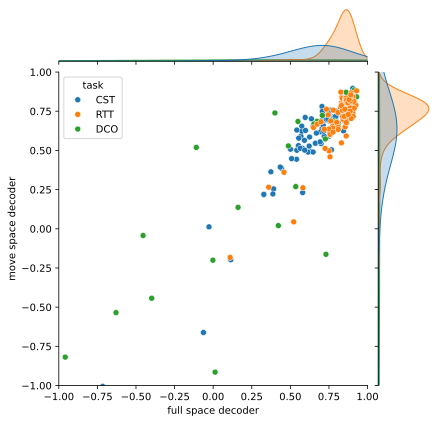

In [31]:
scores = (
    move_scores
    .explode(column=list(preprocessors.keys()))
    .assign(
        ratio=lambda df: df['move space decoder'] / df['full space decoder'],
    )
)
g = sns.jointplot(
    data=scores,
    x='full space decoder',
    y='move space decoder',
    hue='task',
    kind='scatter',
    hue_order=['CST','RTT','DCO'],
)
g.ax_joint.set_xlim(-1, 1)
g.ax_joint.set_ylim(-1, 1)
scores.groupby('task').mean()

<Axes: xlabel='space-component', ylabel='space-component'>

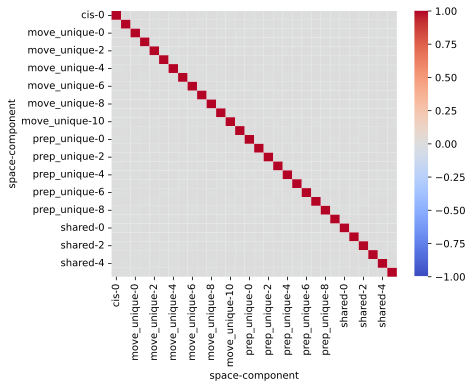

In [32]:
eye = pd.DataFrame(
    np.eye(neural_data.shape[1]),
    index=neural_data.columns,
    columns=neural_data.columns,
)
full_projmat = partition_model.transform(eye)
sns.heatmap(full_projmat.T @ full_projmat,center=0, cmap='coolwarm', vmin=-1, vmax=1)